In [1]:
import os
import sys
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import (
    VarianceThreshold,
    RFE,
    mutual_info_regression,
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import joblib

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))
import config

FEATURES_DIR  = os.path.join("..", config.FEATURES_DATA_DIR)
OUTPUTS_DIR   = os.path.join("..", config.OUTPUTS_METRICS)
PLOTS_DIR     = os.path.join("..", config.OUTPUTS_PLOTS)
CITIES        = list(config.CITIES.keys())
DAYTIME_THR   = config.DAYTIME_THR
SEED          = config.SEED

os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

print("✅ Imports ready")

✅ Imports ready


In [2]:
city_dfs = {}

print("📂 Loading feature CSVs...\n")
for city in CITIES:
    path = os.path.join(FEATURES_DIR, f"{city}_features.csv")
    df   = pd.read_csv(path, index_col="datetime", parse_dates=True)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    city_dfs[city] = df
    print(f"  ✅ {city:<14}  shape={df.shape}")

# We run feature selection on New Delhi as the representative city
# (mid-latitude, high solar, full data, diverse seasons)
REFERENCE_CITY = "new_delhi"
df_ref         = city_dfs[REFERENCE_CITY].copy()

# Target and feature columns
TARGET     = "GHI"
DROP_COLS  = [
    TARGET, "city", "local_hour", "utc_offset",
    "month", "hour", "day_of_year", "year",
    "is_daytime", "is_daytime_clear_sky",
]
FEATURE_COLS = [c for c in df_ref.columns if c not in DROP_COLS]

print(f"\n📋 Reference city    : {REFERENCE_CITY}")
print(f"   Total features   : {len(FEATURE_COLS)}")
print(f"   Total rows       : {len(df_ref):,}")
print(f"\n   All features:\n   {FEATURE_COLS}")

📂 Loading feature CSVs...

  ✅ riyadh          shape=(26232, 58)
  ✅ cairo           shape=(26232, 58)
  ✅ istanbul        shape=(26232, 58)
  ✅ new_delhi       shape=(26232, 58)
  ✅ dubai           shape=(26232, 58)
  ✅ london          shape=(26232, 58)
  ✅ sydney          shape=(26232, 58)
  ✅ tokyo           shape=(26232, 58)
  ✅ los_angeles     shape=(26232, 58)
  ✅ nairobi         shape=(26232, 58)

📋 Reference city    : new_delhi
   Total features   : 53
   Total rows       : 26,232

   All features:
   ['temperature', 'wind_speed', 'humidity', 'clear_sky_ghi', 'precipitation', 'pressure', 'clearness_index', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'GHI_lag1', 'GHI_lag2', 'GHI_lag3', 'GHI_lag6', 'GHI_lag12', 'GHI_lag24', 'GHI_lag48', 'clearness_index_lag1', 'clearness_index_lag2', 'clearness_index_lag3', 'clearness_index_lag6', 'clearness_index_lag12', 'clearness_index_lag24', 'clearness_index_lag48', 'clear_sky_ghi_lag1', 'clear_sky_ghi_lag2', 'cle

In [3]:
# Use daytime only for feature selection
# (nighttime zeros dominate and inflate correlations artificially)
df_day = df_ref[df_ref[TARGET] > DAYTIME_THR].copy()

X = df_day[FEATURE_COLS].copy()
y = df_day[TARGET].copy()

# Scale X for methods that are scale-sensitive
scaler   = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"📊 Dataset prepared")
print(f"   Daytime rows  : {len(X):,}")
print(f"   Features      : {X.shape[1]}")
print(f"   Target range  : {y.min():.1f} – {y.max():.1f} W/m²")
print(f"   Target mean   : {y.mean():.1f} W/m²")

📊 Dataset prepared
   Daytime rows  : 13,019
   Features      : 53
   Target range  : 10.0 – 1025.2 W/m²
   Target mean   : 394.8 W/m²


  STEP 1 — Variance Threshold Filter

  Features before : 53
  Low variance    : 0  []
  Features after  : 53


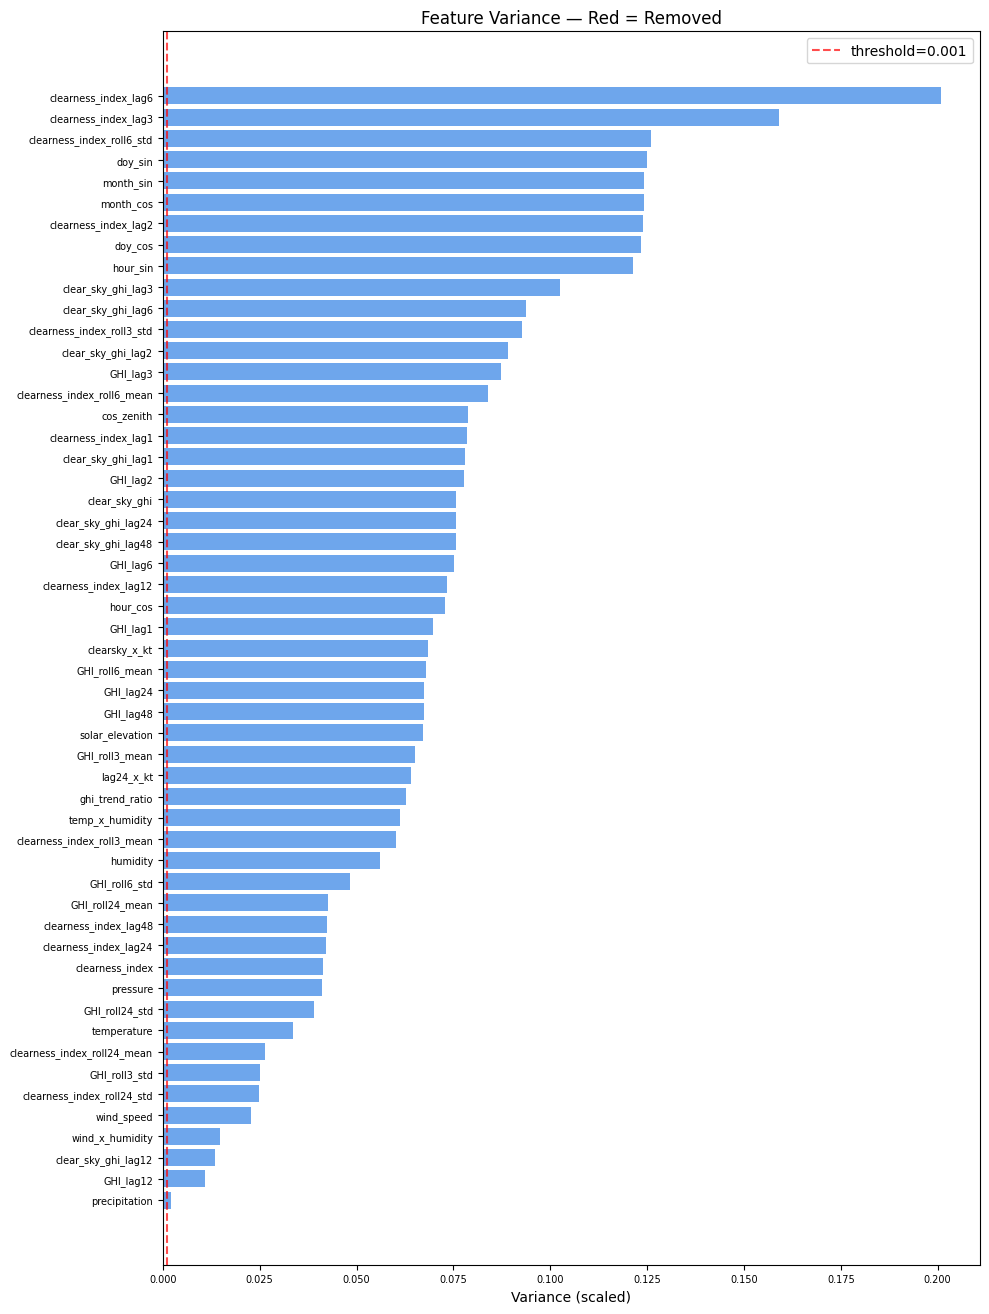

💾 Saved → ..\outputs/plots\05_variance_threshold.png


In [4]:
print("=" * 55)
print("  STEP 1 — Variance Threshold Filter")
print("=" * 55)

vt          = VarianceThreshold(threshold=0.001)
vt.fit(X_scaled)
high_var    = X_scaled.columns[vt.get_support()].tolist()
low_var     = [c for c in X_scaled.columns if c not in high_var]

print(f"\n  Features before : {len(FEATURE_COLS)}")
print(f"  Low variance    : {len(low_var)}  {low_var}")
print(f"  Features after  : {len(high_var)}")

# Variances
var_series = pd.Series(
    vt.variances_, index=X_scaled.columns
).sort_values()

fig, ax = plt.subplots(figsize=(10, max(4, len(FEATURE_COLS) * 0.25)))
colors  = ["#E84A4A" if c in low_var else "#4A90E8"
           for c in var_series.index]
ax.barh(var_series.index, var_series.values, color=colors, alpha=0.8)
ax.axvline(x=0.001, color="red", linestyle="--",
           alpha=0.7, label="threshold=0.001")
ax.set_xlabel("Variance (scaled)")
ax.set_title("Feature Variance — Red = Removed")
ax.legend()
ax.tick_params(labelsize=7)
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "05_variance_threshold.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

  STEP 2 — Pearson Correlation Filter

  Features in     : 53
  Highly correlated (|r|>0.95) dropped : 12
  Dropped         : ['month_sin', 'month_cos', 'clear_sky_ghi_lag6', 'clear_sky_ghi_lag12', 'clear_sky_ghi_lag24', 'clear_sky_ghi_lag48', 'GHI_roll3_mean', 'GHI_roll6_mean', 'GHI_roll24_std', 'lag24_x_kt', 'solar_elevation', 'cos_zenith']
  Features out    : 41


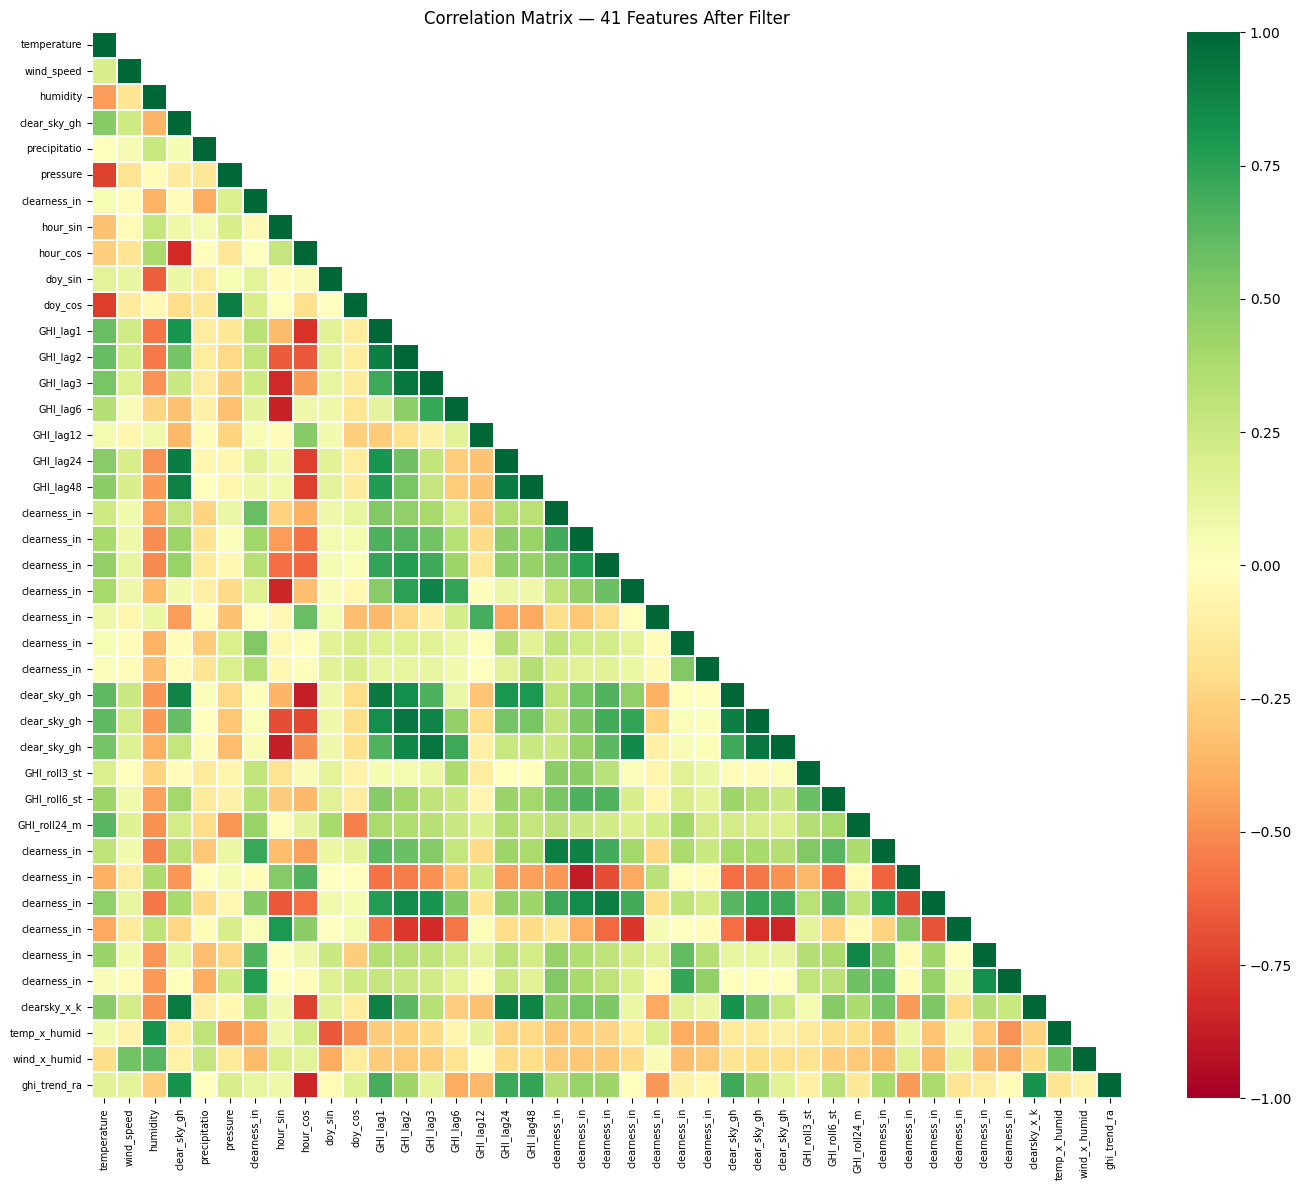

💾 Saved → ..\outputs/plots\05_correlation_filter.png


In [5]:
print("=" * 55)
print("  STEP 2 — Pearson Correlation Filter")
print("=" * 55)

# Work on high-variance features only
X_hv   = X_scaled[high_var]
corr_m = X_hv.corr().abs()

# Find pairs with |r| > 0.95 — one of each pair is redundant
upper_tri   = corr_m.where(
    np.triu(np.ones(corr_m.shape), k=1).astype(bool)
)
to_drop_corr = [
    col for col in upper_tri.columns
    if any(upper_tri[col] > 0.95)
]

after_corr = [c for c in high_var if c not in to_drop_corr]

print(f"\n  Features in     : {len(high_var)}")
print(f"  Highly correlated (|r|>0.95) dropped : {len(to_drop_corr)}")
print(f"  Dropped         : {to_drop_corr}")
print(f"  Features out    : {len(after_corr)}")

# Heatmap of remaining features
fig, ax = plt.subplots(figsize=(14, 12))
corr_remaining = X[after_corr].corr()
mask = np.triu(np.ones_like(corr_remaining, dtype=bool), k=1)
sns.heatmap(
    corr_remaining, ax=ax, mask=mask,
    annot=len(after_corr) <= 20,
    fmt=".2f", annot_kws={"size": 6},
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.3,
    xticklabels=[c[:12] for c in after_corr],
    yticklabels=[c[:12] for c in after_corr],
)
ax.set_title(f"Correlation Matrix — {len(after_corr)} Features After Filter")
ax.tick_params(labelsize=7)
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "05_correlation_filter.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

  STEP 3 — Random Forest Feature Importance
  Training RF on daytime data... (takes ~1 min)

  Top 15 features (RF):
clearsky_x_kt                  9.999899e-01
clear_sky_ghi                  1.003883e-05
GHI_roll6_std                  1.765139e-09
GHI_roll3_std                  1.629403e-09
clearness_index_roll3_mean     1.334648e-09
GHI_lag24                      1.190785e-09
wind_x_humidity                1.187321e-09
clearness_index                1.171582e-09
GHI_lag48                      1.025169e-09
clearness_index_roll24_mean    8.844604e-10
clearness_index_lag24          8.805230e-10
temperature                    8.631908e-10
clearness_index_lag48          8.556232e-10
doy_cos                        8.339958e-10
temp_x_humidity                8.122297e-10


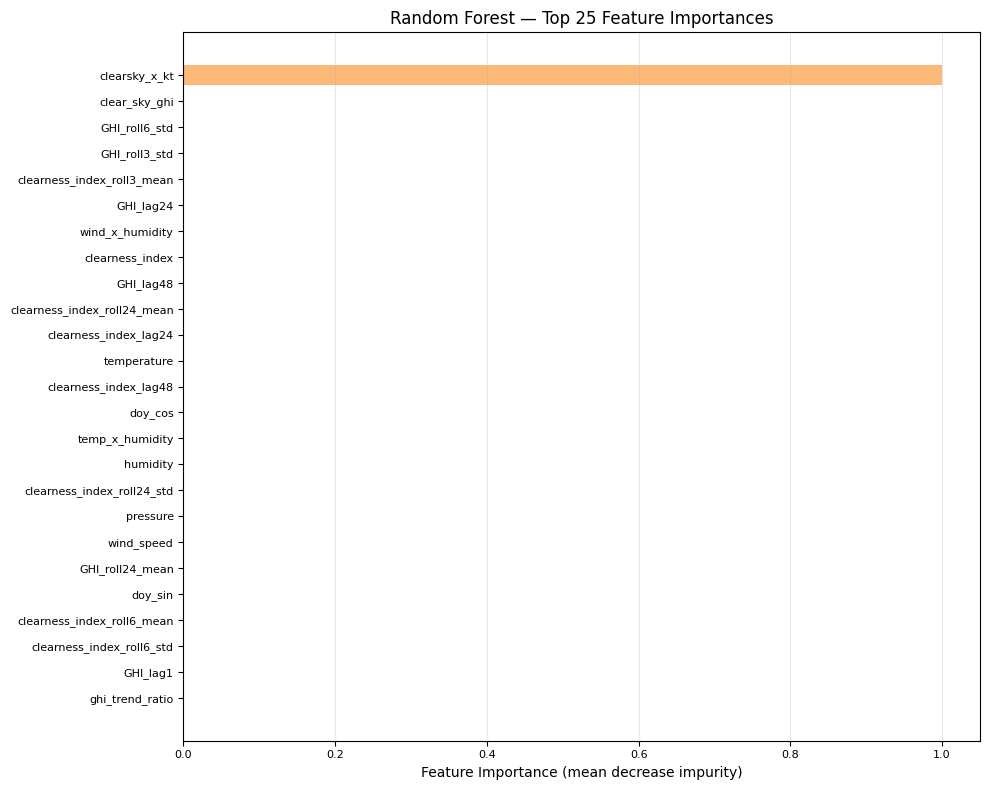

💾 Saved → ..\outputs/plots\05_rf_importance.png


In [6]:
print("=" * 55)
print("  STEP 3 — Random Forest Feature Importance")
print("=" * 55)
print("  Training RF on daytime data... (takes ~1 min)")

X_rf = X[after_corr]
y_rf = y

rf = RandomForestRegressor(
    n_estimators  = 200,
    max_depth     = 12,
    min_samples_leaf = 10,
    n_jobs        = -1,
    random_state  = SEED,
)
rf.fit(X_rf, y_rf)

rf_importance = pd.Series(
    rf.feature_importances_, index=after_corr
).sort_values(ascending=False)

print(f"\n  Top 15 features (RF):")
print(rf_importance.head(15).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_rf  = rf_importance.head(25)
colors  = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_rf)))[::-1]
ax.barh(
    top_rf.index[::-1], top_rf.values[::-1],
    color=colors, alpha=0.85
)
ax.set_xlabel("Feature Importance (mean decrease impurity)")
ax.set_title("Random Forest — Top 25 Feature Importances")
ax.grid(True, alpha=0.3, axis="x")
ax.tick_params(labelsize=8)
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "05_rf_importance.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

  STEP 4 — XGBoost Feature Importance
  Training XGBoost... (takes ~30 sec)

  Top 15 features (XGBoost):
clearsky_x_kt                  0.561575
clear_sky_ghi                  0.148747
GHI_lag24                      0.139458
GHI_lag1                       0.045298
ghi_trend_ratio                0.031450
clearness_index                0.023878
GHI_roll6_std                  0.018274
hour_sin                       0.017966
clearness_index_roll3_mean     0.008839
GHI_roll24_mean                0.001995
clear_sky_ghi_lag1             0.001348
clear_sky_ghi_lag2             0.000293
GHI_roll3_std                  0.000267
clear_sky_ghi_lag3             0.000111
clearness_index_roll24_mean    0.000079


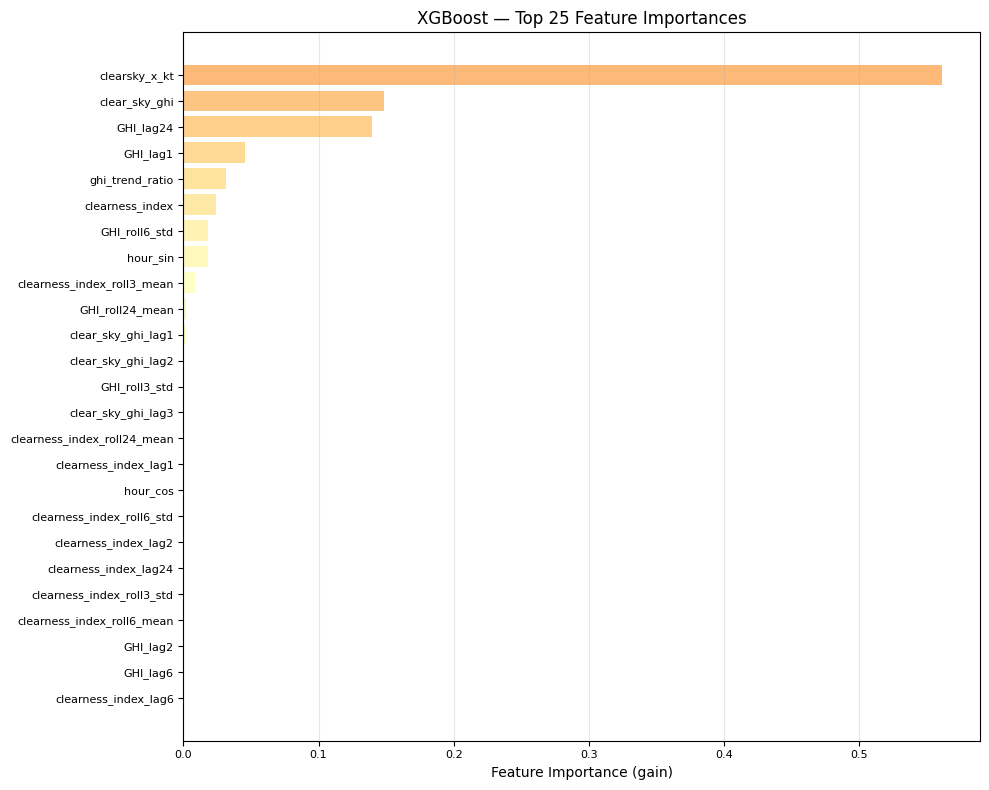

💾 Saved → ..\outputs/plots\05_xgb_importance.png


In [7]:
print("=" * 55)
print("  STEP 4 — XGBoost Feature Importance")
print("=" * 55)
print("  Training XGBoost... (takes ~30 sec)")

X_xgb = X[after_corr]

xgb = XGBRegressor(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = SEED,
    n_jobs            = -1,
    verbosity         = 0,
    eval_metric       = "rmse",
)
xgb.fit(X_xgb, y)

xgb_importance = pd.Series(
    xgb.feature_importances_, index=after_corr
).sort_values(ascending=False)

print(f"\n  Top 15 features (XGBoost):")
print(xgb_importance.head(15).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_xgb = xgb_importance.head(25)
colors  = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_xgb)))[::-1]
ax.barh(
    top_xgb.index[::-1], top_xgb.values[::-1],
    color=colors, alpha=0.85
)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost — Top 25 Feature Importances")
ax.grid(True, alpha=0.3, axis="x")
ax.tick_params(labelsize=8)
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "05_xgb_importance.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

  STEP 5 — Mutual Information Scores
  Computing MI scores... (takes ~20 sec)

  Top 15 features (Mutual Information):
clearsky_x_kt                 7.677873
clear_sky_ghi                 2.373774
GHI_roll6_std                 1.519879
GHI_lag24                     1.221206
GHI_lag1                      1.139543
ghi_trend_ratio               1.053693
GHI_lag48                     1.020290
clear_sky_ghi_lag1            0.968789
hour_sin                      0.658343
clear_sky_ghi_lag2            0.635967
GHI_lag2                      0.624386
GHI_roll3_std                 0.545745
hour_cos                      0.520782
clearness_index_roll6_mean    0.506761
clear_sky_ghi_lag3            0.453063


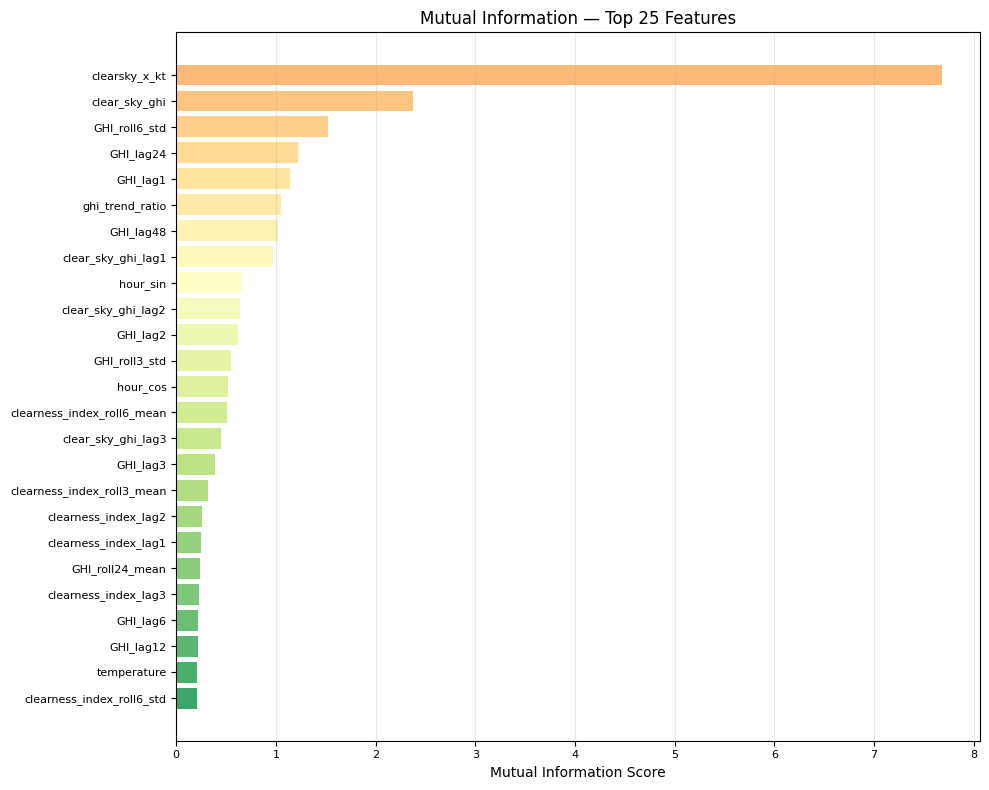

💾 Saved → ..\outputs/plots\05_mutual_information.png


In [8]:
print("=" * 55)
print("  STEP 5 — Mutual Information Scores")
print("=" * 55)
print("  Computing MI scores... (takes ~20 sec)")

mi_scores = mutual_info_regression(
    X[after_corr], y,
    random_state = SEED,
    n_neighbors  = 5,
)
mi_series = pd.Series(
    mi_scores, index=after_corr
).sort_values(ascending=False)

print(f"\n  Top 15 features (Mutual Information):")
print(mi_series.head(15).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_mi  = mi_series.head(25)
colors  = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_mi)))[::-1]
ax.barh(
    top_mi.index[::-1], top_mi.values[::-1],
    color=colors, alpha=0.85
)
ax.set_xlabel("Mutual Information Score")
ax.set_title("Mutual Information — Top 25 Features")
ax.grid(True, alpha=0.3, axis="x")
ax.tick_params(labelsize=8)
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "05_mutual_information.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

In [9]:
print("=" * 55)
print("  STEP 6 — Consensus Feature Selection")
print("=" * 55)

# Normalise each method's scores to [0, 1]
def normalise(s: pd.Series) -> pd.Series:
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s

rf_norm  = normalise(rf_importance)
xgb_norm = normalise(xgb_importance)
mi_norm  = normalise(mi_series)

# Weighted consensus score
# XGBoost gets highest weight — most reliable for tabular data
consensus = (
    0.40 * xgb_norm
  + 0.35 * rf_norm
  + 0.25 * mi_norm
).sort_values(ascending=False)

print(f"\n  Consensus scores (top 20):")
print(consensus.head(20).to_string())

# Select features above a threshold
CONSENSUS_THRESHOLD = 0.15
selected_features   = consensus[
    consensus >= CONSENSUS_THRESHOLD
].index.tolist()

# Always include these critical features regardless of score
MUST_INCLUDE = [
    "clear_sky_ghi",
    "clearness_index",
    "clearsky_x_kt",
    "GHI_lag1",
    "GHI_lag24",
    "solar_elevation",
    "cos_zenith",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]
for f in MUST_INCLUDE:
    if f in after_corr and f not in selected_features:
        selected_features.append(f)
        print(f"  ➕ Force-added  : {f}")

# Remove duplicates and sort by consensus score
selected_features = sorted(
    set(selected_features),
    key=lambda x: consensus.get(x, 0),
    reverse=True
)

print(f"\n  ✅ Final selected features : {len(selected_features)}")
print(f"  {selected_features}")

  STEP 6 — Consensus Feature Selection

  Consensus scores (top 20):
clearsky_x_kt                 1.000000
clear_sky_ghi                 0.182772
GHI_lag24                     0.138520
GHI_lag1                      0.068785
GHI_roll6_std                 0.061955
ghi_trend_ratio               0.056118
hour_sin                      0.033605
GHI_lag48                     0.032638
clear_sky_ghi_lag1            0.031905
clearness_index               0.022496
clear_sky_ghi_lag2            0.020287
GHI_lag2                      0.019714
GHI_roll3_std                 0.017322
hour_cos                      0.016345
clearness_index_roll3_mean    0.016022
clearness_index_roll6_mean    0.015874
clear_sky_ghi_lag3            0.014185
GHI_lag3                      0.012032
GHI_roll24_mean               0.008618
clearness_index_lag2          0.007765
  ➕ Force-added  : clearness_index
  ➕ Force-added  : GHI_lag1
  ➕ Force-added  : GHI_lag24
  ➕ Force-added  : hour_sin
  ➕ Force-added  : hour_cos
  ➕

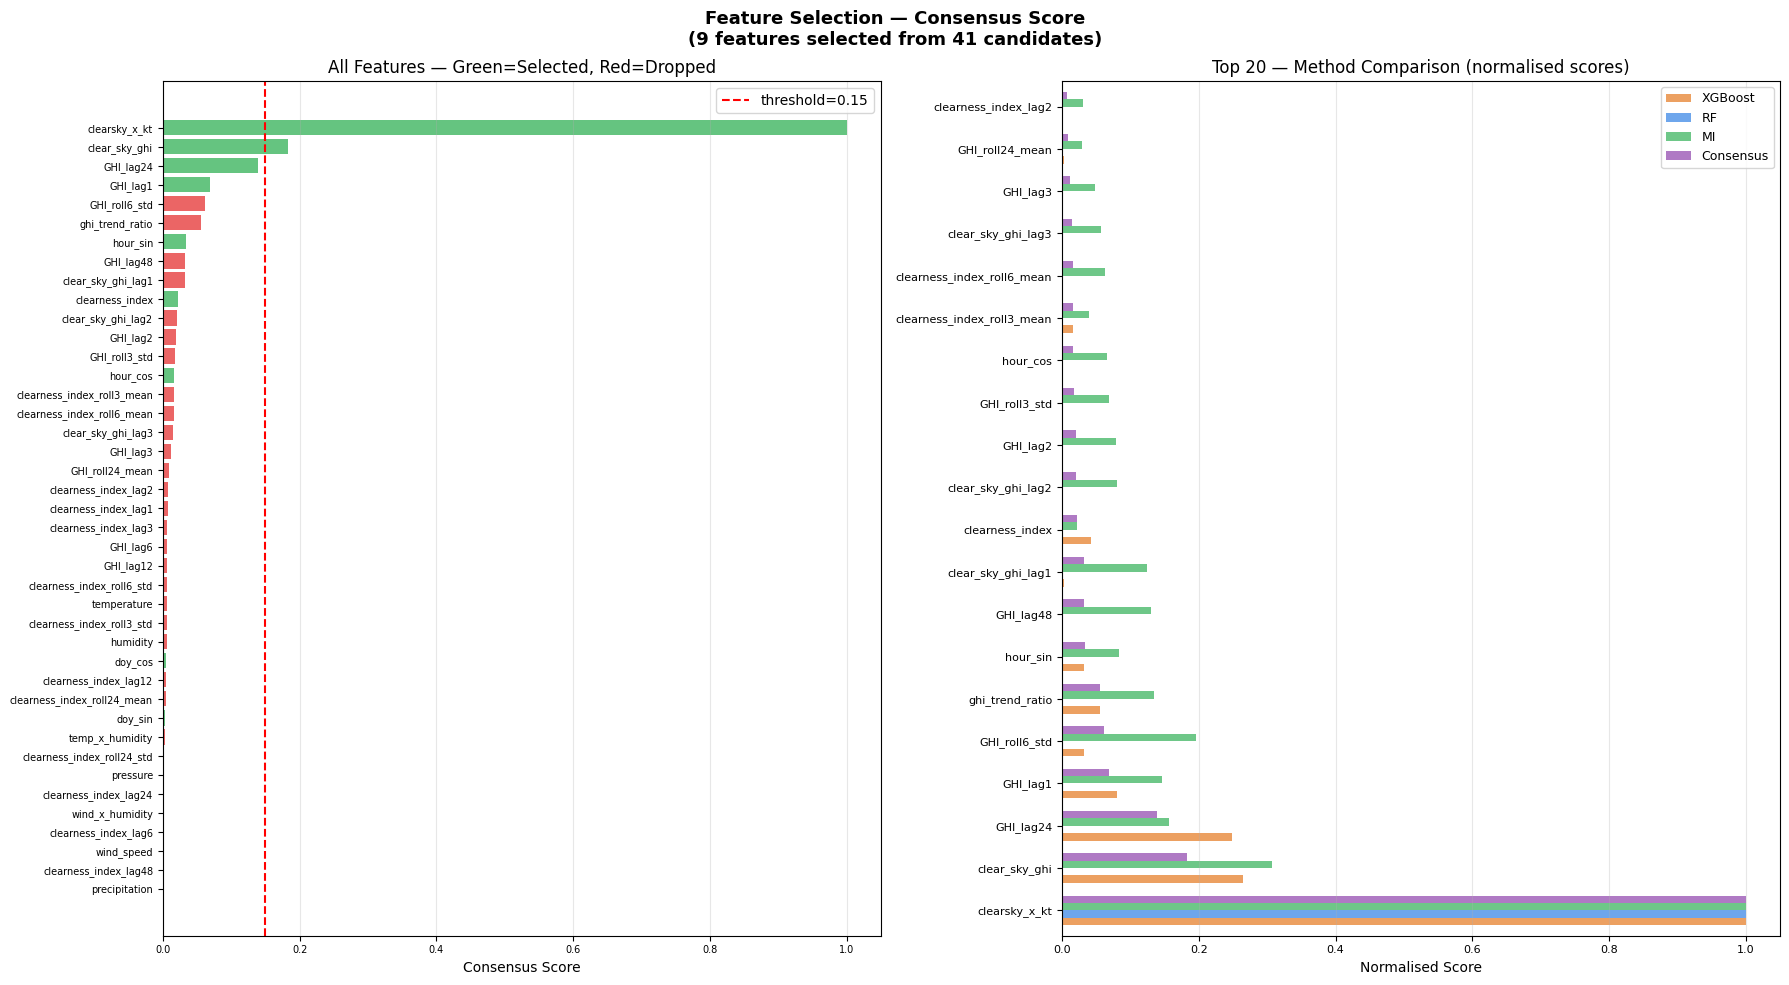

💾 Saved → ..\outputs/plots\05_consensus_selection.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle(
    "Feature Selection — Consensus Score\n"
    f"({len(selected_features)} features selected "
    f"from {len(after_corr)} candidates)",
    fontsize=13, fontweight="bold"
)

# Left: full consensus bar chart
ax = axes[0]
colors = [
    "#4ABA6A" if f in selected_features else "#E84A4A"
    for f in consensus.index[::-1]
]
ax.barh(
    consensus.index[::-1],
    consensus.values[::-1],
    color=colors, alpha=0.85
)
ax.axvline(
    x=CONSENSUS_THRESHOLD, color="red",
    linestyle="--", linewidth=1.5,
    label=f"threshold={CONSENSUS_THRESHOLD}"
)
ax.set_xlabel("Consensus Score")
ax.set_title("All Features — Green=Selected, Red=Dropped")
ax.legend()
ax.tick_params(labelsize=7)
ax.grid(True, alpha=0.3, axis="x")

# Right: method comparison for top 20
ax   = axes[1]
top20_names = consensus.head(20).index.tolist()
comparison  = pd.DataFrame({
    "XGBoost" : xgb_norm[top20_names],
    "RF"      : rf_norm[top20_names],
    "MI"      : mi_norm[top20_names],
    "Consensus": consensus[top20_names],
})
comparison.plot(
    kind="barh", ax=ax, alpha=0.8,
    color=["#E8883A", "#4A90E8", "#4ABA6A", "#9B59B6"],
    width=0.7
)
ax.set_title("Top 20 — Method Comparison (normalised scores)")
ax.set_xlabel("Normalised Score")
ax.tick_params(labelsize=8)
ax.grid(True, alpha=0.3, axis="x")
ax.legend(fontsize=9)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "05_consensus_selection.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

In [11]:
# Save feature list as JSON — loaded by all model notebooks
feature_config = {
    "selected_features"    : selected_features,
    "target"               : TARGET,
    "reference_city"       : REFERENCE_CITY,
    "consensus_threshold"  : CONSENSUS_THRESHOLD,
    "total_candidates"     : len(after_corr),
    "total_selected"       : len(selected_features),
    "method_weights"       : {
        "xgboost" : 0.40,
        "rf"      : 0.35,
        "mi"      : 0.25,
    },
    "must_include"         : MUST_INCLUDE,
}

json_path = os.path.join(OUTPUTS_DIR, "selected_features.json")
with open(json_path, "w") as f:
    json.dump(feature_config, f, indent=2)

# Also save consensus scores as CSV
scores_df = pd.DataFrame({
    "feature"   : consensus.index,
    "consensus" : consensus.values,
    "xgboost"   : xgb_norm.reindex(consensus.index).values,
    "rf"        : rf_norm.reindex(consensus.index).values,
    "mi"        : mi_norm.reindex(consensus.index).values,
    "selected"  : [f in selected_features for f in consensus.index],
})
csv_path = os.path.join(OUTPUTS_DIR, "feature_scores.csv")
scores_df.to_csv(csv_path, index=False)

print("=" * 55)
print("  NOTEBOOK 05 — COMPLETE")
print("=" * 55)
print(f"\n  📁 Selected features JSON → {json_path}")
print(f"  📁 Feature scores CSV    → {csv_path}")
print(f"\n  ✅ {len(selected_features)} features selected:")
for i, f in enumerate(selected_features, 1):
    score = consensus.get(f, 0)
    print(f"     {i:>2}. {f:<35}  score={score:.4f}")

print(f"\n  Ready for → 06_baseline_model.ipynb")

  NOTEBOOK 05 — COMPLETE

  📁 Selected features JSON → ..\outputs/metrics\selected_features.json
  📁 Feature scores CSV    → ..\outputs/metrics\feature_scores.csv

  ✅ 9 features selected:
      1. clearsky_x_kt                        score=1.0000
      2. clear_sky_ghi                        score=0.1828
      3. GHI_lag24                            score=0.1385
      4. GHI_lag1                             score=0.0688
      5. hour_sin                             score=0.0336
      6. clearness_index                      score=0.0225
      7. hour_cos                             score=0.0163
      8. doy_cos                              score=0.0046
      9. doy_sin                              score=0.0035

  Ready for → 06_baseline_model.ipynb
